In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler,StandardScaler,RobustScaler,OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import recall_score,f1_score

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

**Step-1:** Data Collection

In [85]:
data = pd.read_csv(r"C:\Users\varun\Downloads\diabetes_prediction_dataset.csv")

In [86]:
df = data.copy()

In [87]:
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


**Step-2:** EDA

In [88]:
df.shape

(100000, 9)

In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [90]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [91]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [92]:
df.describe(include=["O"])

,gender,smoking_history
count,100000,100000
unique,3,6
top,Female,No Info
freq,58552,35816


In [93]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [94]:
df.duplicated().sum()

np.int64(3854)

In [95]:
df.drop_duplicates(inplace=True)

In [96]:
df["diabetes"].value_counts()

diabetes
0    87664
1     8482
Name: count, dtype: int64

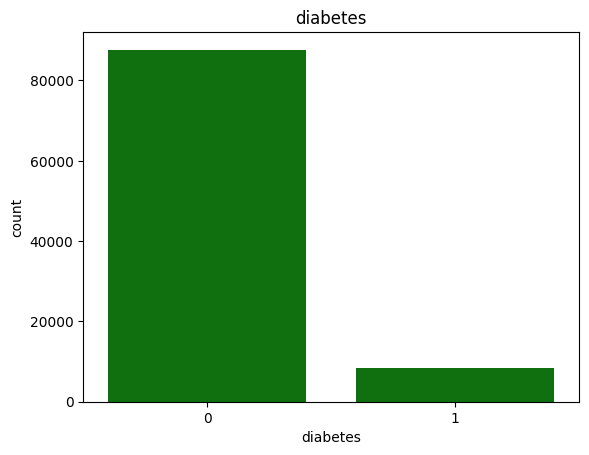

In [97]:
sns.countplot(data=df, x='diabetes',color='green')
plt.title("diabetes")
plt.show()

**Observations:**
- the target variable is extremely imbalanced data

In [98]:
num_col = df.select_dtypes(include = ["int64","float64"]).columns
cat_col = df.select_dtypes(include=["object"]).columns

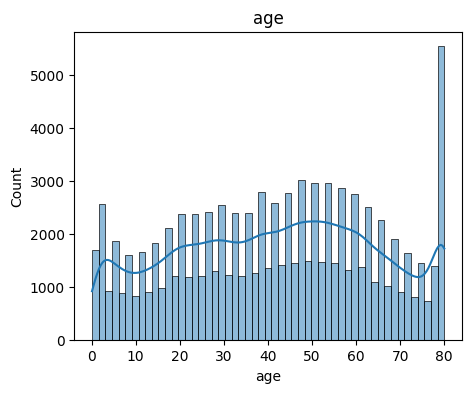

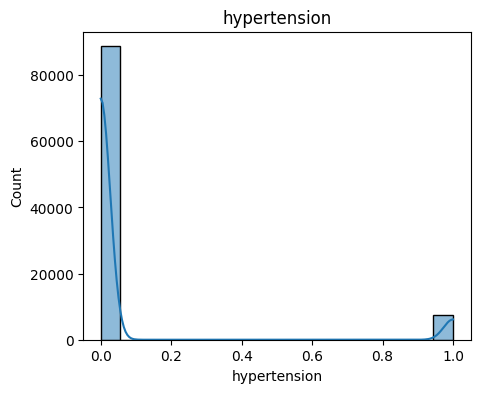

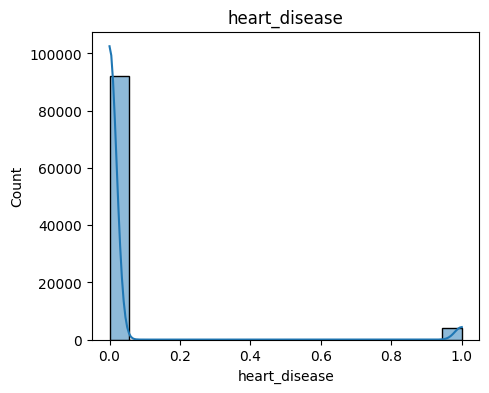

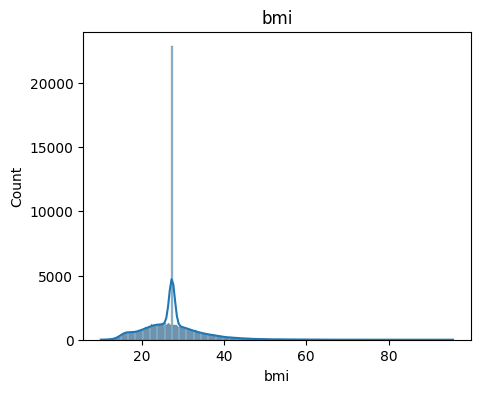

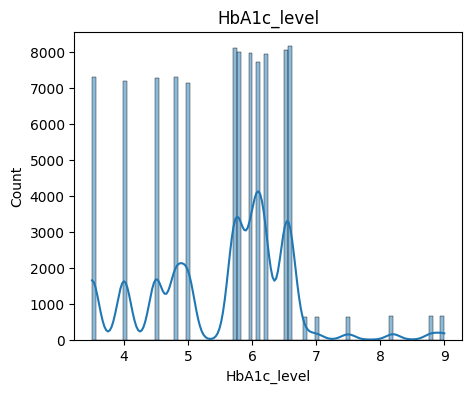

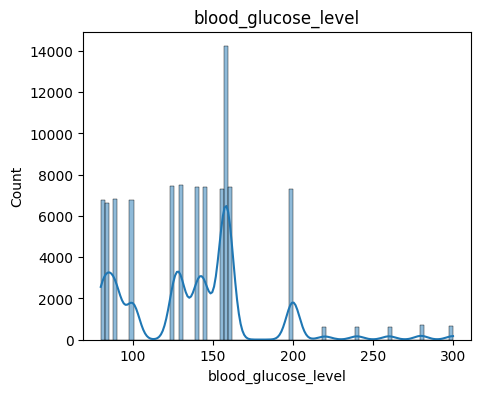

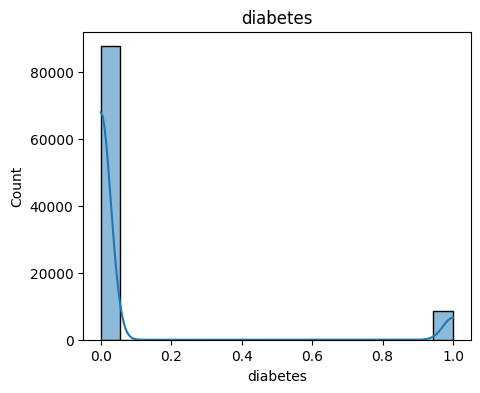

In [99]:
# univariate analysis
for col in num_col:
    plt.figure(figsize=(5,4))
    sns.histplot(df[col],kde =True)
    plt.title(col)
    plt.show()

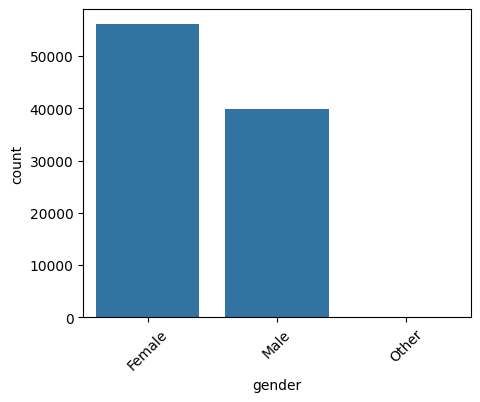

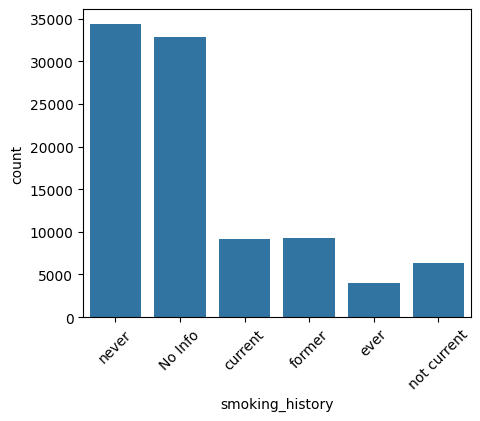

In [100]:
for col in cat_col:
    plt.figure(figsize=(5,4))
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=45)
    plt.show()

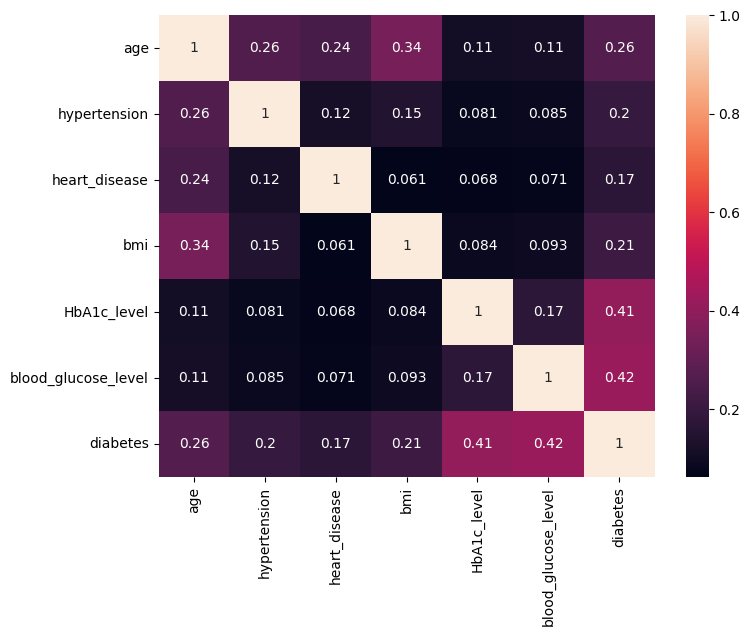

In [101]:
# bivariate analysis
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

**Observations:**
- The heatmap indicates that blood glucose level (0.42) and HbA1c level (0.40) are the most influential features for predicting diabetes. Age (0.26), BMI (0.21), hypertension (0.20), and heart disease (0.17) show weaker positive correlations with the target variable. Additionally, no pair of independent features exhibits a very high correlation (greater than 0.7), suggesting that multicollinearity is not a significant concern in this dataset.

**Step-3:** Feature engineering

In [102]:
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99994,Female,36.0,0,0,No Info,24.60,4.8,145,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [103]:
df['smoking_history'] = df['smoking_history'].replace('No Info','never')

In [104]:
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,never,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99994,Female,36.0,0,0,never,24.60,4.8,145,0
99996,Female,2.0,0,0,never,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [105]:
data = df.copy()

**Step-4:** X and y

In [106]:
X = df.drop('diabetes',axis=1)
y = df['diabetes']

**Step-5:** train,test split data

In [107]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify = y)

In [108]:
print(X_train.shape,X_test.shape)

(76916, 8) (19230, 8)


In [109]:
print(y_train.shape,y_test.shape)

(76916,) (19230,)


**Step-6:** Preprocessing Pipeline

In [110]:
num_features = X_train.select_dtypes(include=['int64','float64']).columns
cat_features = X_train.select_dtypes(include=['object']).columns

In [111]:
num_pipeline = Pipeline([('scaler', StandardScaler())])
cat_pipeline = Pipeline([('encoder', OneHotEncoder(handle_unknown='ignore',sparse_output=False))])

In [112]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

**Step-7:** Baseline Model

In [113]:
models = {
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

for name, model in models.items():

    pipe = Pipeline([('preprocessor', preprocessor),('smote', SMOTE(random_state=42)),('model', model)])

    pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)

    print(name)
    print("Recall:", recall_score(y_test, pred))
    print(classification_report(y_test, pred))

    print()

KNN
Recall: 0.7971698113207547
              precision    recall  f1-score   support

           0       0.98      0.92      0.95     17534
           1       0.48      0.80      0.60      1696

    accuracy                           0.91     19230
   macro avg       0.73      0.86      0.77     19230
weighted avg       0.94      0.91      0.92     19230


Naive Bayes
Recall: 0.9911556603773585
              precision    recall  f1-score   support

           0       1.00      0.40      0.57     17534
           1       0.14      0.99      0.24      1696

    accuracy                           0.45     19230
   macro avg       0.57      0.70      0.41     19230
weighted avg       0.92      0.45      0.54     19230


Decision Tree
Recall: 0.7476415094339622
              precision    recall  f1-score   support

           0       0.98      0.96      0.97     17534
           1       0.65      0.75      0.70      1696

    accuracy                           0.94     19230
   macro avg   

**observations:**
- we have KNN with recall of 79 with accuracy of 91 %, Naive Bayes with recall of 0.99 with accuracy of 45%
- we have Decision Tree with recall of 74 and acuracy of 94 %.
- so we prefer Decision Tree model, KNN model

**Step-8:** Hyperparameter tunning

In [114]:
# KNN
knn_pipeline = Pipeline([("preprocessing",preprocessor),
                         ('smote', SMOTE(random_state=42)),
                        ("model",KNeighborsClassifier())])

In [115]:
param_grid_knn = {
    'model__n_neighbors':list(range(3, 31, 2)),
    'model__weights':['uniform','distance'],
    'model__metric':['euclidean','manhattan']
}

In [116]:
grid_knn = GridSearchCV(
    knn_pipeline,param_grid_knn,cv=5,scoring='f1',n_jobs=-1)

In [117]:
grid_knn.fit(X_train,y_train)

print("Best KNN Parameters:")
print(grid_knn.best_params_)

print("Best KNN CV Score:")
print(grid_knn.best_score_)

Best KNN Parameters:
{'model__metric': 'manhattan', 'model__n_neighbors': 3, 'model__weights': 'distance'}
Best KNN CV Score:
0.6459377666994597


In [118]:
# Decision Tree
dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', DecisionTreeClassifier(random_state=42))
])

In [119]:
param_grid_dt = {
    'model__criterion': ['gini', 'entropy'],
    'model__max_depth': [3, 5, 7, 10, 15, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

In [120]:
grid_dt = GridSearchCV(dt_pipeline,param_grid_dt,cv=5,scoring='f1',n_jobs=-1)

grid_dt.fit(X_train, y_train)

print("Best Decision Tree Parameters:")
print(grid_dt.best_params_)

print("\nBest F1 Score:")
print(grid_dt.best_score_)

Best Decision Tree Parameters:
{'model__criterion': 'gini', 'model__max_depth': 3, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}

Best F1 Score:
0.7995485549908211


**Step-9:** Model evaluation

In [121]:
best_knn = grid_knn.best_estimator_

In [122]:
knn_pred = best_knn.predict(X_test)

In [123]:
print("KNN F1_Score:")
print(f1_score(y_test,knn_pred))

KNN F1_Score:
0.6442451420029895


In [124]:
print(confusion_matrix(y_test,knn_pred))

[[16509  1025]
 [  403  1293]]


In [125]:
knn_prob = best_knn.predict_proba(X_test)[:,1]

In [126]:
print("KNN ROC-AUC:")
print(roc_auc_score(y_test,knn_prob))

KNN ROC-AUC:
0.8853483246027664


**Decision Tree Evaluation**

In [127]:
best_dt = grid_dt.best_estimator_

In [128]:
dt_pred = best_dt.predict(X_test)

In [129]:
print("Desicion Tree F1_Score:")
print(f1_score(y_test,dt_pred))

Desicion Tree F1_Score:
0.8081517919887562


In [130]:
print(confusion_matrix(y_test,dt_pred))

[[17534     0]
 [  546  1150]]


In [44]:
dt_prob = best_dt.predict_proba(X_test)[:,1]

In [45]:
print("Decision tree ROC-AUC:")
print(roc_auc_score(y_test,dt_prob))

Decision tree ROC-AUC:
0.9714609728591996


**Step-9:** Best model selection

In [46]:
knn_acc = f1_score(
    y_test,
    best_knn.predict(X_test)
)

In [47]:
knn_acc

0.7360774818401937

In [48]:
dt_acc = f1_score(
    y_test,
    best_dt.predict(X_test)
)

In [49]:
dt_acc

0.8117850953206239

In [131]:
if knn_acc > dt_acc:
    best_model = best_knn
    print("Best Model = KNN")
else:
    best_model = best_dt
    print("Best Model = Decison Tree")

Best Model = Decison Tree


**Step-11:** Save complete pipeline

In [132]:
import joblib

joblib.dump(best_model, "diabetes_pipeline.pkl")

['diabetes_pipeline.pkl']